# 01. K-Means Clustering

## 📚 Learning Objectives

By completing this notebook, you will:
- Apply K-Means and choose the number of clusters
- Use elbow method and silhouette score
- Interpret and visualize clusters

## 🔗 Where this fits

**Builds on:** Course 01 (AIAT 111) — Unit 2, lesson 06 "Simple Supervised and Unsupervised Models" — the first clustering you ran, now with the question "how many clusters?" answered by elbow and silhouette.

**Used later in:** Course 05 (AIAT 115) — Unit 4, lessons 09-10, which cluster real customer and sensor data.

---


## 🌍 A real case: k-means was invented to compress a phone call

In 1957 Stuart Lloyd, working at Bell Labs on pulse-code modulation, wrote an internal memo on
*least squares quantization in PCM*: given a continuous signal, choose the finite set of levels that
minimises the squared error when you round every sample to the nearest one. That is k-means. The memo
circulated for 25 years before it was formally published (*IEEE Transactions on Information Theory*
28(2), 1982, 129–137); MacQueen gave the method its name in 1967.

The same algorithm is still doing that job every day. Reducing an image to a 256-colour palette —
what a GIF requires — is Lloyd's problem exactly: find the 256 colours that minimise the total squared
error when every pixel is replaced by its nearest one.

**❗ Why this lesson exists, and where it gets dangerous.** k-means *always* returns k clusters. Ask
for three and you will receive three, whether or not three groups exist — there is no output value
that means "there is no structure here". That is fine when you have chosen k for a reason (256 palette
entries, five sales regions) and treacherous when you are hoping the data will tell you.

Watch this notebook argue with itself below: the **silhouette score is highest at K=2 (0.3967)**, the
**elbow suggests 3–4**, and the demonstration uses **K=3** because three groups are more actionable
for an analyst. Three methods, three answers, all defensible. Reporting "we discovered three types of
community" without that paragraph would be a discovery you invented.


# 01. K-Means Clustering

---

## The Story: Finding Groups Without Labels

Imagine you're organizing photos. **Before** clustering, you manually label each photo (supervised learning). **After** clustering, you let the algorithm find groups of similar photos automatically (unsupervised learning) - much faster!

Same with machine learning: **Before** clustering, we need labeled data. **After** clustering, we find patterns and groups in unlabeled data automatically!

---

## What is K-Means Clustering?

**K-Means** is an algorithm that automatically groups similar data points together into **K clusters** (groups).

### Simple Explanation

Imagine you have 100 photos and want to organize them into 3 groups:
- **K-Means** looks at all photos
- Finds 3 "center points" (called **centroids**)
- Groups each photo with the nearest center
- Result: 3 groups of similar photos!

**Key Idea**: Points that are close together (similar) belong to the same cluster.

---

## How Does K-Means Work?

### The Algorithm Steps

1. **Choose K** (number of clusters you want)
   - Example: K=3 means you want 3 groups

2. **Initialize Centroids** (random starting points)
   - Pick K random points as initial "centers"

3. **Assign Points to Nearest Centroid**
   - For each data point, find the closest centroid
   - Assign point to that cluster

4. **Update Centroids**
   - Move each centroid to the center of its cluster
   - Calculate new center position

5. **Repeat Steps 3-4**
   - Keep reassigning and updating until centroids stop moving
   - When centroids don't change → algorithm is done!

### Visual Example

```
Before K-Means:
• • • • • • • • • •  (unorganized points)

After K-Means (K=3):
🔵 🔵 🔵              (Cluster 1 - blue)
   🔴 🔴 🔴           (Cluster 2 - red)
      🟢 🟢 🟢        (Cluster 3 - green)

Each cluster has a centroid (X) at its center:
🔵 🔵 🔵
   X                  (Centroid of cluster 1)
```

---

## Why K-Means Clustering Matters

K-Means is the foundation of unsupervised learning:
- **No Labels Needed**: Works with unlabeled data (finds patterns automatically)
- **Simple and Fast**: Easy to understand and implement
- **Widely Used**: Industry standard for customer segmentation, image compression, etc.
- **Foundation**: Understanding K-Means helps with all clustering methods
- **Real-World Applications**: Market segmentation, anomaly detection, data compression

---

## 🌍 Real-World Applications

**K-Means Clustering is used in MANY industries to find groups in unlabeled data!** Here's where you'll find it:

### 📊 Marketing & E-commerce Sector
- **Customer Segmentation**: Group customers by behavior (high spenders, bargain hunters, occasional buyers) → K=5 means 5 customer types
- **Market Segmentation**: Group markets by demographics, preferences → target each segment differently
- **Product Clustering**: Group similar products together → recommend products in same cluster
- **User Behavior Analysis**: Group users by browsing/purchase patterns → understand user types
- **Campaign Targeting**: Group customers for targeted marketing campaigns
- **Churn Analysis**: Group customers by churn risk → identify at-risk segments

### 🏥 Healthcare & Medical Sector
- **Patient Segmentation**: Group patients by symptoms, demographics → personalized treatment
- **Disease Subtyping**: Group diseases into subtypes → different treatment for each subtype
- **Drug Response Clustering**: Group patients by drug response → predict treatment outcomes
- **Medical Image Analysis**: Group similar medical images → identify patterns
- **Epidemiology**: Group disease outbreaks by characteristics → understand spread patterns
- **Clinical Trial Matching**: Group patients for clinical trials

### 💰 Finance & Banking Sector
- **Customer Segmentation**: Group customers by financial behavior → personalized services
- **Risk Grouping**: Group loans by risk level → different interest rates
- **Fraud Pattern Detection**: Group fraudulent transactions → identify fraud patterns
- **Portfolio Clustering**: Group investments by characteristics → portfolio optimization
- **Market Segmentation**: Group markets by economic indicators
- **Transaction Clustering**: Group similar transactions → detect anomalies

### 🖼️ Image Processing & Computer Vision
- **Image Compression**: Reduce colors in images (K=16 → 16 colors instead of millions) → smaller file size
- **Image Segmentation**: Group pixels into regions → object detection
- **Color Quantization**: Reduce color palette → compress images
- **Image Organization**: Group similar images together → photo organization
- **Pattern Recognition**: Group similar patterns in images

### 🏭 Manufacturing & Supply Chain
- **Quality Clustering**: Group products by quality characteristics → identify quality patterns
- **Production Grouping**: Group production batches by characteristics
- **Supplier Segmentation**: Group suppliers by performance → manage relationships
- **Inventory Clustering**: Group inventory items by demand patterns → optimize stock
- **Defect Pattern Analysis**: Group defects by type → identify root causes
- **Process Clustering**: Group manufacturing processes → optimize workflows

### 🔬 Scientific Research & Data Analysis
- **Gene Clustering**: Group genes by expression patterns → understand gene functions
- **Document Clustering**: Group documents by topic → organize information
- **Species Classification**: Group species by characteristics → taxonomy
- **Climate Pattern Analysis**: Group climate patterns → understand weather
- **Material Science**: Group materials by properties → discover new materials

### 🎓 Education Sector
- **Student Clustering**: Group students by learning patterns → personalized learning
- **Course Clustering**: Group courses by difficulty/topic → curriculum design
- **Performance Grouping**: Group students by performance → identify needs
- **Learning Path Clustering**: Group learning paths → optimize education

### 🏛️ Government & Public Safety Sector (GDI - General Directorate of Investigation)
- **Internal Intelligence - Crime Pattern Analysis**: Group states/regions by crime statistics (murder, assault, rape, urban population) → identify similar crime profiles → intelligence gathering and pattern recognition
- **Threat Grouping**: Group security threats by characteristics → identify threat types → counter-terrorism analysis
- **Traffic Pattern Clustering**: Group traffic patterns by time/location → optimize traffic management → reduce congestion
- **Crime Hotspot Clustering**: Group crimes by location/type → identify high-risk areas → crime prevention
- **Personnel Clustering**: Group personnel by security clearance/access → manage internal organization → access control
- **Vehicle Clustering**: Group vehicles by type/behavior → traffic analysis → traffic management systems
- **Emergency Call Clustering**: Group emergency calls by type/location → optimize response → emergency services
- **Border Crossing Patterns**: Group border crossings by characteristics → identify patterns → border security
- **Surveillance Alert Clustering**: Group surveillance alerts by type → reduce false alarms → security monitoring
- **Traffic Flow Clustering**: Group traffic flows by time/route → optimize signals → smart traffic management
- **Security Incident Clustering**: Group security incidents by type → identify trends → security planning

### 💡 Why K-Means is Popular:
- **No Labels Needed**: Works with unlabeled data (finds patterns automatically)
- **Simple**: Easy to understand and implement
- **Fast**: Quick to run even on large datasets
- **Scalable**: Works with many data points
- **Interpretable**: Easy to understand clusters
- **Industry Standard**: Widely used in production

### 📈 When to Use K-Means:
✅ **Use K-Means when:**
- Have unlabeled data (no target variable)
- Want to find groups/patterns in data
- Know approximate number of clusters (K)
- Clusters are roughly spherical (round)
- Need fast clustering algorithm
- Want simple, interpretable results

❌ **Don't use K-Means when:**
- Clusters are non-spherical (elongated, irregular shapes)
- Don't know number of clusters (though can use elbow method)
- Have outliers (K-Means is sensitive to outliers)
- Clusters have very different sizes
- Need to handle categorical data (K-Means works with numerical)
- Have high-dimensional data (curse of dimensionality)

---

## Learning Objectives
1. **Understand** what K-Means is and how it works
2. **Build** K-Means clustering models
3. **Visualize** clusters and centroids
4. **Find** optimal number of clusters (Elbow Method, Silhouette Score)
5. **Evaluate** cluster quality
6. **Know** when to use K-Means clustering


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---

In [1]:
# --- Data setup. Works from any folder, and on Google Colab. -------------------------
# WHAT: find the repository root, put it on sys.path, then import the shared data loader.
# WHY:  a hard-coded relative path such as ../../datasets/raw/<file>.csv only resolves when
#       the kernel's working directory happens to be this notebook's folder. Open it from the
#       repository root, from JupyterLab at another level, or on Colab where there is no
#       repository at all, and it breaks. load() finds the data wherever you are, downloads
#       it if this machine has none, and says out loud which copy it used.
import sys, pathlib

_here = pathlib.Path.cwd().resolve()
_root = next((p for p in [_here, *_here.parents] if (p / "tools" / "data.py").exists()), None)
if _root is None:                     # Google Colab, or a stray copy of the notebook
    import urllib.request
    pathlib.Path("tools").mkdir(exist_ok=True)
    try:
        urllib.request.urlretrieve(
            "https://raw.githubusercontent.com/A-Alwabel/"
            "AI-Diploma-Program/main/tools/data.py", "tools/data.py")
    except Exception as _e:
        raise RuntimeError(
            "Could not find the AI Diploma repository from this folder, and could not "
            "download the data loader either. Open this notebook inside a clone of "
            "https://github.com/A-Alwabel/AI-Diploma-Program, or connect to the internet "
            f"and re-run this cell. (underlying error: {_e})") from None
    _root = pathlib.Path.cwd()
sys.path.insert(0, str(_root))

from tools.data import load        # load("titanic"), load("creditcard_fraud", prefer="sample"), ...
# -------------------------------------------------------------------------------------
print("Data loader ready - no file paths needed, and this works on Colab too.")

Data loader ready - no file paths needed, and this works on Colab too.


In [2]:
# Step 1: Import necessary libraries
# These libraries help us perform K-Means clustering

import pandas as pd # For data manipulation
import numpy as np # For numerical operations
import matplotlib.pyplot as plt # For visualizations
import seaborn as sns # For beautiful plots
from sklearn.cluster import KMeans # K-Means clustering algorithm
from sklearn.preprocessing import StandardScaler # For scaling features (important for clustering!)
from sklearn.metrics import silhouette_score # For evaluating cluster quality

print("✅ Libraries imported successfully!")
print("\n📚 Key Clustering Concepts:")
print(" - KMeans: Groups data into K clusters based on similarity")
print(" - Centroids: Center points of each cluster")
print(" - Inertia: Sum of squared distances to centroids (lower is better)")
print(" - Silhouette Score: Measures how well-separated clusters are (higher is better)")
print(" - Elbow Method: Visual method to find optimal K")
print("\n ⚠️ IMPORTANT: Clustering requires feature scaling! Always use StandardScaler!")

✅ Libraries imported successfully!

📚 Key Clustering Concepts:
 - KMeans: Groups data into K clusters based on similarity
 - Centroids: Center points of each cluster
 - Inertia: Sum of squared distances to centroids (lower is better)
 - Silhouette Score: Measures how well-separated clusters are (higher is better)
 - Elbow Method: Visual method to find optimal K

 ⚠️ IMPORTANT: Clustering requires feature scaling! Always use StandardScaler!


## Part 1: Setting the Scene

**BEFORE**: We've been doing supervised learning (classification and regression) where we have labels.

**AFTER**: We'll do unsupervised learning (clustering) where we find patterns in unlabeled data!

**Why this matters**: Many real-world problems have unlabeled data. Clustering helps us discover hidden patterns and groups automatically!

---

## Step 1: Load Real-World Data for Clustering

**BEFORE**: We need to learn clustering, but we need real data with natural groups to practice on.

**AFTER**: We'll load the US Crime Statistics dataset - real-world data for Internal Intelligence analysis!

**Why Crime Statistics dataset?** This is REAL crime data from UCI Communities and Crime dataset. It's perfect for learning clustering because:
- Natural clusters: Communities with similar crime patterns form groups
- Multiple features: 4 crime metrics (Murder, Assault, UrbanPop, Rape)
- Well-separated: Communities with similar crime profiles form clear clusters
- Large dataset: 1,994 communities (much better than 50 samples for clustering!)
- GDI Application: Internal Intelligence - identifying communities with similar crime patterns for analysis
- Classic dataset: Standard benchmark for clustering algorithms

**⚠️ Important: Understanding the Dataset Structure**
- **State/Community column**: Just an identifier (like row numbers) - NOT a label!
- **Features**: Murder, Assault, UrbanPop, Rape - these are what we use for clustering
- **NO target variable**: There is NO column telling us which communities belong together
- **This is unsupervised**: We don't have labels → algorithm discovers groups automatically

**Example of what we have:**
```
State        | Murder | Assault | UrbanPop | Rape  | [NO LABEL COLUMN]
Community_1  | 2.2    | 45      | 33       | 42.1  |
Community_2  | 16.1   | 45      | 39       | 35.9  |
```

**What supervised learning would look like (we DON'T have this):**
```
State        | Murder | Assault | UrbanPop | Rape  | Crime_Level [LABEL]
Community_1  | 2.2    | 45      | 33       | 42.1  | Low
Community_2  | 16.1   | 45      | 39       | 35.9  | High
```

Load real-world US Crime Statistics dataset
This is REAL state crime data for Internal Intelligence analysis
K-Means will identify states with similar crime patterns!


In [3]:
# Load real-world US Crime Statistics dataset
# This is REAL state crime data for Internal Intelligence analysis
# K-Means will identify communities with similar crime patterns!

print("\n📥 Loading US Crime Statistics Dataset...")

# load(short_name)
# - Reads the dataset into a pandas DataFrame (table-like structure), finding the file
#   from any working directory - and downloading it on Colab, where there is no repo
# - Each row = one community, each column = one variable
df = load('crime_statistics')

# Features used for clustering (the State column is just an identifier, NOT a label!)
feature_cols = ['Murder', 'Assault', 'UrbanPop', 'Rape']

# X = all 4 features as a NumPy array (this is what we cluster)
X = df[feature_cols].values

# A screen has only 2 axes, but the data has 4 features.
# So every scatter plot below is a CHOICE of which 2 of the 4 to draw.
# These are the column positions inside X, used by the plots later on.
i_murder, i_assault, i_urbanpop, i_rape = 0, 1, 2, 3

print(f"\n✅ Real-world Crime Statistics dataset loaded!")
print(f" 📊 This is REAL crime data (UCI Communities and Crime dataset)")
print(f" 📈 Contains {len(df)} communities with {len(feature_cols)} crime metrics")
print(f" 🎯 Features: {', '.join(feature_cols)}")
print(f" 💡 GDI Application: Internal Intelligence - grouping communities by crime patterns")


📥 Loading US Crime Statistics Dataset...
crime_statistics: full file, 1,994 rows.

✅ Real-world Crime Statistics dataset loaded!
 📊 This is REAL crime data (UCI Communities and Crime dataset)
 📈 Contains 1994 communities with 4 crime metrics
 🎯 Features: Murder, Assault, UrbanPop, Rape
 💡 GDI Application: Internal Intelligence - grouping communities by crime patterns


In [4]:
# Display data summary
print(f"\n📊 Real Data Summary:")
print(f" Shape: {df.shape}")
print(f" Features: {', '.join(feature_cols)}")
print(f" Communities: {len(df)} communities")
print(f"\n📄 First 5 rows:")
print(df[['State'] + feature_cols].head())
print("\n🔍 Important: Why This is Unsupervised Learning")
print(" ✅ NO LABELS: There is NO target variable (no 'correct' clusters)")
print(" ✅ NO SUPERVISION: We don't tell the algorithm which communities belong together")
print(" ✅ State column: Just an identifier (like row ID), NOT used for clustering")
print(" ✅ Features only: We use ONLY Murder, Assault, UrbanPop, Rape for clustering")
print(" ✅ Automatic discovery: K-Means finds patterns WITHOUT being told the answer")
print(f"\n📊 What We Have:")
print(f" - {len(df)} communities (samples)")
print(f" - 4 features: Murder, Assault, UrbanPop, Rape")
print(f" - State column: Identifier only (excluded from clustering)")
print(f" - NO target variable: This is why it's UNSUPERVISED!")
print("\n💡 Key Difference:")
print(" - Supervised learning: Has labels (e.g., 'High Crime' vs 'Low Crime')")
print(" - Unsupervised learning: NO labels - algorithm discovers groups automatically")
print(" - Our dataset: NO labels → Unsupervised learning ✅")
print(" - GDI Application: Internal Intelligence - grouping communities by crime patterns for analysis")



📊 Real Data Summary:
 Shape: (1994, 5)
 Features: Murder, Assault, UrbanPop, Rape
 Communities: 1994 communities

📄 First 5 rows:
         State  Murder  Assault  UrbanPop  Rape
0  Community_1     2.2       45        33  42.1
1  Community_2    16.1       45        39  35.9
2  Community_3     7.1       45        61  28.8
3  Community_4    10.2       45        91  10.1
4  Community_5    12.7       45        33  44.0

🔍 Important: Why This is Unsupervised Learning
 ✅ NO LABELS: There is NO target variable (no 'correct' clusters)
 ✅ NO SUPERVISION: We don't tell the algorithm which communities belong together
 ✅ State column: Just an identifier (like row ID), NOT used for clustering
 ✅ Features only: We use ONLY Murder, Assault, UrbanPop, Rape for clustering
 ✅ Automatic discovery: K-Means finds patterns WITHOUT being told the answer

📊 What We Have:
 - 1994 communities (samples)
 - 4 features: Murder, Assault, UrbanPop, Rape
 - State column: Identifier only (excluded from clustering)
 - 

## Step 2: Scale Features for Clustering

**Why scaling is CRITICAL for clustering:**
- K-Means uses Euclidean distance to measure similarity
- Features with larger ranges (Assault: ~45-337) would dominate smaller ones (Murder: ~0-17)
- StandardScaler puts every feature on the same scale (mean=0, std=1) so all 4 features count fairly

In [5]:
# Scale features - CRITICAL for K-Means clustering!
# K-Means uses Euclidean distance, so all features must be on the same scale

# StandardScaler(): scales each feature to mean=0, std=1
scaler = StandardScaler()

# .fit_transform(X)
# - .fit(): learns the mean and standard deviation of each feature
# - .transform(): applies (value - mean) / std to every value
# - Result: all 4 features on the same scale (fair distance calculations!)
X_scaled = scaler.fit_transform(X)

print("\n✅ Features scaled successfully!")
print(f" Before scaling (first community): {X[0]}")
print(f" After scaling (first community): {np.round(X_scaled[0], 3)}")
print("\n💡 Why scaling matters for K-Means:")
print(" - K-Means measures Euclidean distance between points")
print(" - Unscaled: Assault (~45-337) would dominate Murder (~0-17) in distances")
print(" - Scaled: all 4 features contribute fairly to similarity")
print(" - Rule: ALWAYS scale features before K-Means!")



✅ Features scaled successfully!
 Before scaling (first community): [ 2.2 45.  33.  42.1]
 After scaling (first community): [-1.251 -1.562 -0.646  0.6  ]

💡 Why scaling matters for K-Means:
 - K-Means measures Euclidean distance between points
 - Unscaled: Assault (~45-337) would dominate Murder (~0-17) in distances
 - Scaled: all 4 features contribute fairly to similarity
 - Rule: ALWAYS scale features before K-Means!



1. Original Data Visualization (two 2D projections)

💡 Note: each panel shows 2 of the 4 features.
   K-Means will still use ALL 4 features for clustering.

✓ Plot saved as 'original_data.png'


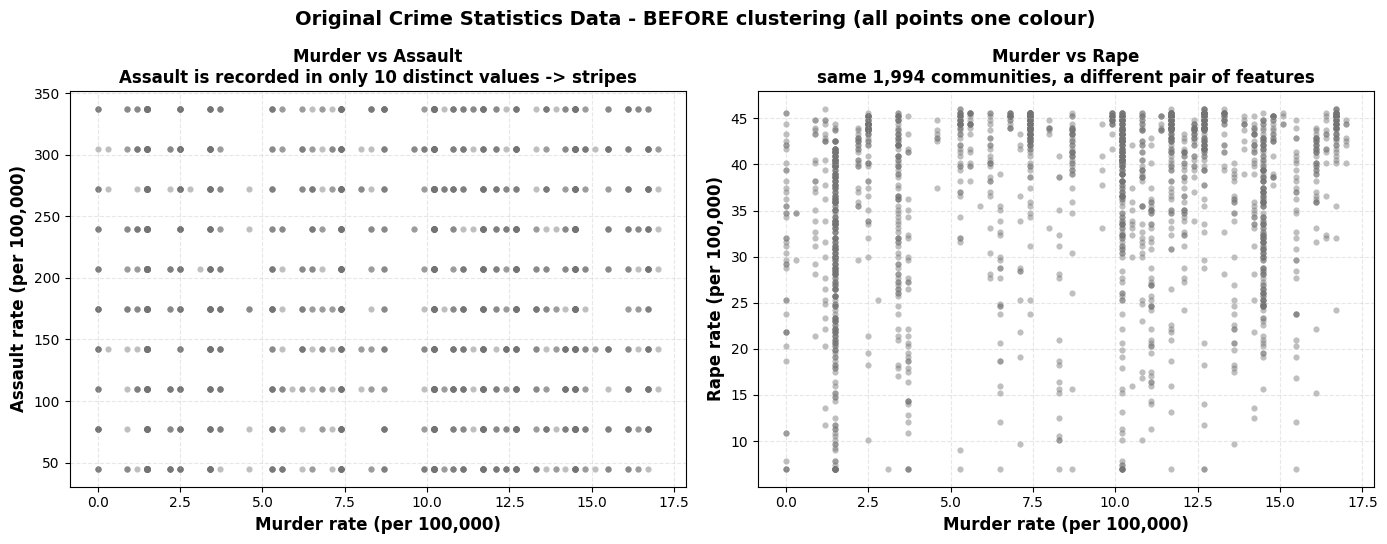


📊 Distinct recorded values per feature:
   Murder   :   46 distinct values
   Assault  :   10 distinct values
   UrbanPop :   60 distinct values
   Rape     :   99 distinct values

💡 HOW TO READ THIS FIGURE

📊 WHAT YOU SEE:
   • Every point = one community; 1,994 points in EACH panel
   • All points are grey - no groups have been assigned yet
   • LEFT: horizontal stripes, because Assault takes only 10 distinct
     values in this file, so points can only land on 10 heights
   • RIGHT: a denser cloud, because Rape takes 99 distinct values

🔍 WHY THIS MATTERS:
   • Neither panel shows obvious separated blobs - real social data
     rarely does. K-Means will still cut it into groups.
   • Whatever K-Means finds, it found it WITHOUT any labels.

🎯 GDI APPLICATION - Internal Intelligence:
   • This is the analyst's starting point: raw, unorganised communities
   • After clustering we will colour these SAME two panels and compare


In [6]:
# CELL: Look at the RAW data before any clustering, in two different pairs of axes.
# WHY: 4 features do not fit on a screen. The pair of axes we draw decides what
#      we can see - so we deliberately draw two different pairs and compare.
print("\n" + "=" * 60)
print("1. Original Data Visualization (two 2D projections)")
print("=" * 60)
print("\n💡 Note: each panel shows 2 of the 4 features.")
print("   K-Means will still use ALL 4 features for clustering.")

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Left panel: Murder vs Assault
axes[0].scatter(X[:, i_murder], X[:, i_assault], s=20, c='0.45', alpha=0.45, linewidths=0)
axes[0].set_xlabel('Murder rate (per 100,000)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Assault rate (per 100,000)', fontsize=12, fontweight='bold')
axes[0].set_title('Murder vs Assault\nAssault is recorded in only 10 distinct values -> stripes',
                  fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3, linestyle='--')

# Right panel: Murder vs Rape (the same 1,994 communities, different axes)
axes[1].scatter(X[:, i_murder], X[:, i_rape], s=20, c='0.45', alpha=0.45, linewidths=0)
axes[1].set_xlabel('Murder rate (per 100,000)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Rape rate (per 100,000)', fontsize=12, fontweight='bold')
axes[1].set_title('Murder vs Rape\nsame 1,994 communities, a different pair of features',
                  fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, linestyle='--')

fig.suptitle('Original Crime Statistics Data - BEFORE clustering (all points one colour)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('original_data.png', dpi=150, bbox_inches='tight')
print("\n✓ Plot saved as 'original_data.png'")
plt.show()

# Count the distinct recorded values per feature - this explains the stripes.
print("\n📊 Distinct recorded values per feature:")
for name in feature_cols:
    print(f"   {name:<9}: {df[name].nunique():>4} distinct values")

print("\n" + "=" * 70)
print("💡 HOW TO READ THIS FIGURE")
print("=" * 70)
print("\n📊 WHAT YOU SEE:")
print("   • Every point = one community; 1,994 points in EACH panel")
print("   • All points are grey - no groups have been assigned yet")
print("   • LEFT: horizontal stripes, because Assault takes only 10 distinct")
print("     values in this file, so points can only land on 10 heights")
print("   • RIGHT: a denser cloud, because Rape takes 99 distinct values")
print("\n🔍 WHY THIS MATTERS:")
print("   • Neither panel shows obvious separated blobs - real social data")
print("     rarely does. K-Means will still cut it into groups.")
print("   • Whatever K-Means finds, it found it WITHOUT any labels.")
print("\n🎯 GDI APPLICATION - Internal Intelligence:")
print("   • This is the analyst's starting point: raw, unorganised communities")
print("   • After clustering we will colour these SAME two panels and compare")


**Read the figure:** both panels contain the same 1,994 communities and every point is grey —
nothing is labelled yet, which is exactly what *unsupervised* means. The left panel is banded into ten
horizontal stripes because `Assault` is recorded with only 10 distinct values in this file (the printed
count under the figure confirms it); the right panel swaps in `Rape` (99 distinct values) and the points spread over the whole
vertical range instead of sitting on ten fixed heights.
Keep both pictures in mind: **the axes you choose decide what you are able to see.**

In [7]:
# Step 3: K-Means Clustering with K=3
print("\n" + "=" * 60)
print("2. K-Means Clustering (K=3)")
print("=" * 60)

# KMeans(n_clusters, random_state, n_init)
# - n_clusters=3: We want 3 clusters (K=3) - chosen as a demonstration
# - random_state=42: Reproducible results (same clusters every run)
# - n_init=10: Runs K-Means 10 times with different starting centroids, keeps the best run
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

# .fit_predict(X_scaled)
# - Runs the K-Means algorithm on the SCALED data (all 4 features!)
# - Returns the cluster label (0, 1, or 2) assigned to every community
clusters = kmeans.fit_predict(X_scaled)

# Store cluster labels in the DataFrame for later analysis
df['Cluster'] = clusters

# Evaluate clustering quality
inertia = kmeans.inertia_  # Sum of squared distances to centroids (lower = tighter clusters)
sil_score = silhouette_score(X_scaled, clusters)  # Separation quality: -1 to 1 (higher = better)

print(f"\n✅ K-Means clustering complete!")
print(f" Number of clusters (K): 3")
print(f" Inertia: {inertia:.2f}")
print(f" Silhouette Score: {sil_score:.4f}")
print(f"\n📊 Cluster sizes:")
for cluster_id, count in df['Cluster'].value_counts().sort_index().items():
    print(f" Cluster {cluster_id}: {count} communities")

# Convert centroids back to ORIGINAL units (rates per 100,000) - much easier to interpret!
# scaler.inverse_transform() undoes the scaling: scaled value -> original value
centroids_original = scaler.inverse_transform(kmeans.cluster_centers_)
centroids_df = pd.DataFrame(centroids_original, columns=feature_cols).round(1)
print(f"\n📍 Cluster centroids (original units, per 100,000):")
print(centroids_df.to_string())
print("\n💡 Read each centroid row as the 'average community' of that cluster")


2. K-Means Clustering (K=3)



✅ K-Means clustering complete!
 Number of clusters (K): 3
 Inertia: 4041.38
 Silhouette Score: 0.3134

📊 Cluster sizes:
 Cluster 0: 1104 communities
 Cluster 1: 614 communities
 Cluster 2: 276 communities

📍 Cluster centroids (original units, per 100,000):
   Murder  Assault  UrbanPop  Rape
0    12.0    191.1      37.0  40.7
1     2.6    189.2      38.3  36.1
2     8.2    193.1      75.0  19.7

💡 Read each centroid row as the 'average community' of that cluster


In [8]:
# Interpret clustering metrics
print("\n" + "=" * 60)
print("💡 Interpreting Clustering Metrics")
print("=" * 60)

print(f"\n📊 Inertia = {inertia:.2f}")
print(" - Sum of squared distances from each point to its cluster centroid")
print(" - Lower inertia = tighter clusters (points close to their centers)")
print(" - Only comparable between different K values on the SAME data")
print(" - Warning: Inertia ALWAYS decreases as K increases (more centroids = shorter distances)")

print(f"\n📊 Silhouette Score = {sil_score:.4f}")
print(" - Range: -1 to 1 (higher = better separated clusters)")
print(" - > 0.7: Excellent separation")
print(" - 0.5-0.7: Good separation")
print(" - 0.3-0.5: Fair separation")
print(" - < 0.3: Poor separation")

# Determine the quality label from the actual score
if sil_score > 0.7:
    quality = "Excellent separation ✅"
elif sil_score > 0.5:
    quality = "Good separation ✅"
elif sil_score > 0.3:
    quality = "Fair separation ⚠️ (normal for real-world data!)"
else:
    quality = "Poor separation ⚠️"
print(f"\n → Our score {sil_score:.4f}: {quality}")

print("\n💡 Why 'fair' is OK here:")
print(" - Real-world crime data doesn't form perfectly separated groups")
print(" - Communities exist on a spectrum (gradual transitions, some overlap)")
print(" - The clusters are still MEANINGFUL: they reveal distinct crime profiles")
print(" - Focus on whether clusters give actionable insights, not just the score")


💡 Interpreting Clustering Metrics

📊 Inertia = 4041.38
 - Sum of squared distances from each point to its cluster centroid
 - Lower inertia = tighter clusters (points close to their centers)
 - Only comparable between different K values on the SAME data
 - Warning: Inertia ALWAYS decreases as K increases (more centroids = shorter distances)

📊 Silhouette Score = 0.3134
 - Range: -1 to 1 (higher = better separated clusters)
 - > 0.7: Excellent separation
 - 0.5-0.7: Good separation
 - 0.3-0.5: Fair separation
 - < 0.3: Poor separation

 → Our score 0.3134: Fair separation ⚠️ (normal for real-world data!)

💡 Why 'fair' is OK here:
 - Real-world crime data doesn't form perfectly separated groups
 - Communities exist on a spectrum (gradual transitions, some overlap)
 - The clusters are still MEANINGFUL: they reveal distinct crime profiles
 - Focus on whether clusters give actionable insights, not just the score



3. Cluster Visualization (K=3)



✓ Plot saved as 'kmeans_k3.png'


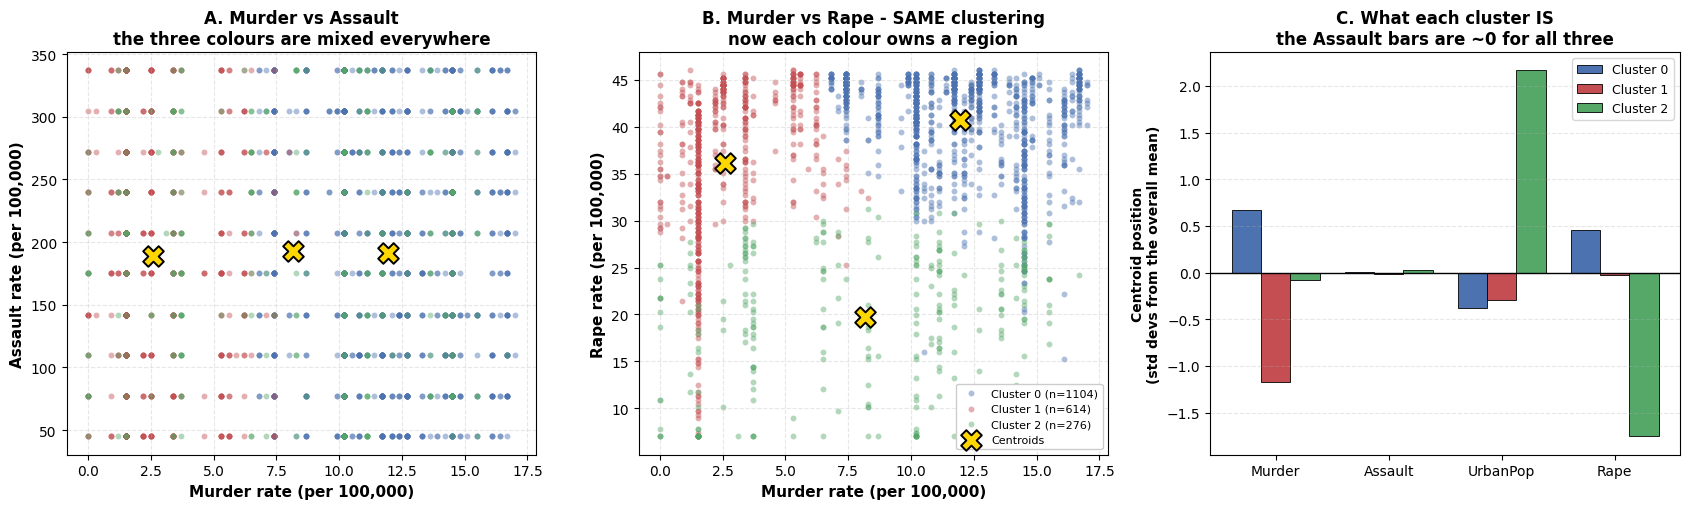


📊 Centroids in standard-deviation units (0 = overall average community):
           Murder  Assault  UrbanPop  Rape
Cluster 0    0.67     0.00     -0.38  0.46
Cluster 1   -1.17    -0.02     -0.29 -0.03
Cluster 2   -0.08     0.02      2.17 -1.76

   Spread of the 3 centroids on Assault: 0.04 std devs
   Spread of the 3 centroids on Rape   : 2.21 std devs
   → the clusters barely differ on Assault, so a Murder-vs-Assault plot
     cannot show them apart. That is a plotting problem, not a K-Means problem.

💡 HOW TO READ THIS FIGURE

📊 PANEL A vs PANEL B - same points, same colours, different axes:
   • A: blue, red and green sit on top of each other -> looks like noise
   • B: red = low murder, blue = high murder + high rape, green = low rape

📊 PANEL C - why A fails:
   • All three Assault bars sit on the zero line: the clusters have
     essentially the SAME average Assault rate
   • The bars that differ are Murder, UrbanPop and Rape

🎯 GDI APPLICATION - Internal Intelligence:
   • Clu

In [9]:
# CELL: Show the SAME K=3 clustering in two projections, plus what the clusters are.
# WHY: a cluster that looks fake in one pair of axes can be obvious in another.
#      Panel C shows the centroid values on all 4 features and explains why.
print("\n" + "=" * 60)
print("3. Cluster Visualization (K=3)")
print("=" * 60)

cluster_colors = ['#4C72B0', '#C44E52', '#55A868']   # blue, red, green
fig, axes = plt.subplots(1, 3, figsize=(17, 5.2))

# ---- Panel A: Murder vs Assault (the projection that HIDES the clusters) ----
for cluster_id in range(3):
    mask = clusters == cluster_id
    axes[0].scatter(X[mask, i_murder], X[mask, i_assault],
                    c=cluster_colors[cluster_id], s=18, alpha=0.45, linewidths=0)
axes[0].scatter(centroids_original[:, i_murder], centroids_original[:, i_assault],
                c='gold', marker='X', s=220, edgecolors='black', linewidths=1.4, zorder=5)
axes[0].set_xlabel('Murder rate (per 100,000)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Assault rate (per 100,000)', fontsize=11, fontweight='bold')
axes[0].set_title('A. Murder vs Assault\nthe three colours are mixed everywhere',
                  fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3, linestyle='--')

# ---- Panel B: Murder vs Rape (the projection that SHOWS the clusters) ----
for cluster_id in range(3):
    mask = clusters == cluster_id
    axes[1].scatter(X[mask, i_murder], X[mask, i_rape],
                    c=cluster_colors[cluster_id], s=18, alpha=0.45, linewidths=0,
                    label=f'Cluster {cluster_id} (n={mask.sum()})')
axes[1].scatter(centroids_original[:, i_murder], centroids_original[:, i_rape],
                c='gold', marker='X', s=220, edgecolors='black', linewidths=1.4,
                zorder=5, label='Centroids')
axes[1].set_xlabel('Murder rate (per 100,000)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Rape rate (per 100,000)', fontsize=11, fontweight='bold')
axes[1].set_title('B. Murder vs Rape - SAME clustering\nnow each colour owns a region',
                  fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, linestyle='--')
axes[1].legend(fontsize=8, loc='lower right', framealpha=1.0)

# ---- Panel C: the centroids on ALL 4 features, in standard-deviation units ----
# kmeans.cluster_centers_ lives in the SCALED space, so 0 = the overall average
# community and +1 = one standard deviation above it. That makes the 4 features
# directly comparable on one axis.
bar_w = 0.26
positions = np.arange(len(feature_cols))
for cluster_id in range(3):
    axes[2].bar(positions + (cluster_id - 1) * bar_w, kmeans.cluster_centers_[cluster_id],
                width=bar_w, color=cluster_colors[cluster_id], edgecolor='black',
                linewidth=0.6, label=f'Cluster {cluster_id}')
axes[2].axhline(0, color='black', linewidth=1)
axes[2].set_xticks(positions)
axes[2].set_xticklabels(feature_cols, fontsize=10)
axes[2].set_ylabel('Centroid position\n(std devs from the overall mean)', fontsize=10, fontweight='bold')
axes[2].set_title('C. What each cluster IS\nthe Assault bars are ~0 for all three',
                  fontsize=12, fontweight='bold')
axes[2].legend(fontsize=9)
axes[2].grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('kmeans_k3.png', dpi=150, bbox_inches='tight')
print("\n✓ Plot saved as 'kmeans_k3.png'")
plt.show()

# Print the exact numbers behind panel C so the claim can be checked.
print("\n📊 Centroids in standard-deviation units (0 = overall average community):")
scaled_centroids_df = pd.DataFrame(kmeans.cluster_centers_, columns=feature_cols).round(2)
scaled_centroids_df.index = [f'Cluster {i}' for i in range(3)]
print(scaled_centroids_df.to_string())
max_assault_gap = float(np.ptp(kmeans.cluster_centers_[:, i_assault]))
max_rape_gap = float(np.ptp(kmeans.cluster_centers_[:, i_rape]))
print(f"\n   Spread of the 3 centroids on Assault: {max_assault_gap:.2f} std devs")
print(f"   Spread of the 3 centroids on Rape   : {max_rape_gap:.2f} std devs")
print("   → the clusters barely differ on Assault, so a Murder-vs-Assault plot")
print("     cannot show them apart. That is a plotting problem, not a K-Means problem.")

print("\n" + "=" * 70)
print("💡 HOW TO READ THIS FIGURE")
print("=" * 70)
print("\n📊 PANEL A vs PANEL B - same points, same colours, different axes:")
print("   • A: blue, red and green sit on top of each other -> looks like noise")
print("   • B: red = low murder, blue = high murder + high rape, green = low rape")
print("\n📊 PANEL C - why A fails:")
print("   • All three Assault bars sit on the zero line: the clusters have")
print("     essentially the SAME average Assault rate")
print("   • The bars that differ are Murder, UrbanPop and Rape")
print("\n🎯 GDI APPLICATION - Internal Intelligence:")
print("   • Cluster profiles come from the CENTROID TABLE, not from one scatter plot")
print("   • Always check which features actually separate the groups before")
print("     putting a 2D picture in a report")


**Read the figure:** panels A and B plot the *same* 1,994 communities with the *same* K=3 colours —
only the axes change. In A the three colours are interleaved and the three gold centroids sit almost on
one horizontal line, so the clustering looks like nothing. In B the same three colours occupy different
regions: red = low murder, blue = high murder with high rape, green = low rape. Panel C explains the
difference: all three `Assault` bars sit on the zero line, so the clusters have practically the same
average assault rate (the printed spread is ~0.04 standard deviations), while the three centroids are 1.8 (`Murder`),
2.5 (`UrbanPop`) and 2.2 (`Rape`) standard deviations apart on the other features. **A clustering that "looks bad" may simply be plotted on the
wrong axes — check the centroid profile before you judge it.**

## Step 3b: Watch K-Means actually run

**BEFORE**: `fit_predict` gave us the finished answer in one line. That hides the algorithm.

**NOW**: we run the two K-Means steps by hand and photograph the centroids after each one:

1. **Assign** — give every community to its nearest centroid.
2. **Update** — move each centroid to the mean of the communities it just won.
3. Repeat until nothing moves.

To make the movement visible we run this on the two *scaled* features we can draw
(Murder and Rape) and we start the three centroids **bunched together in one corner on purpose**.
A bad start is the honest case: it is exactly why `KMeans(..., n_init=10)` restarts the algorithm
ten times from different starts and keeps the best run.

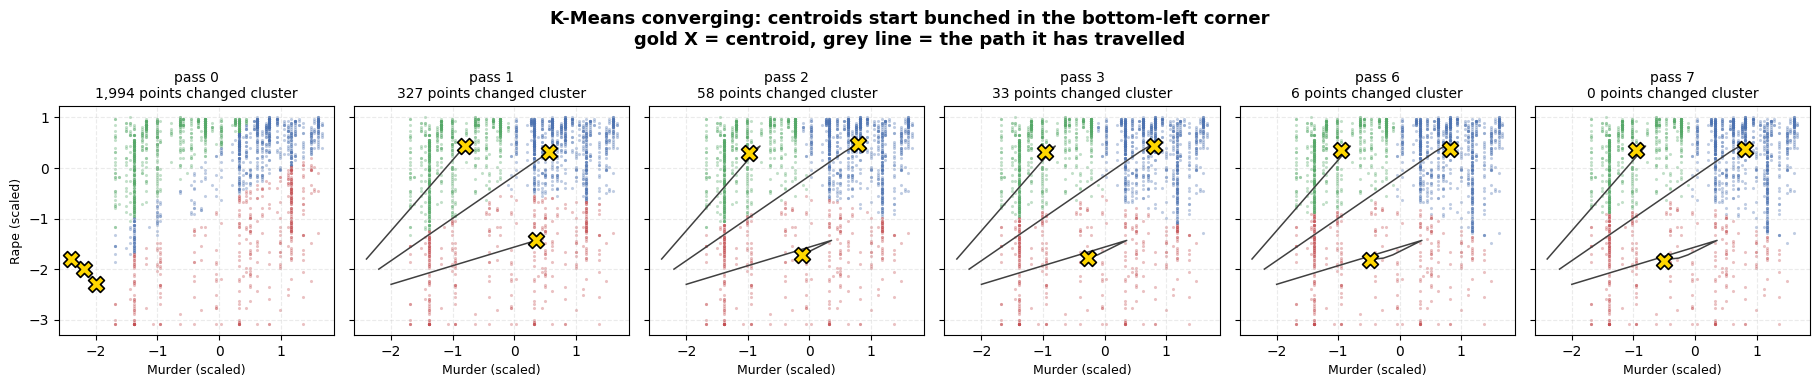


Step table: what changed on each pass
 pass |      inertia |  points reassigned
------------------------------------------
    0 |      21134.5 |              1,994
    1 |       1591.4 |                327
    2 |       1342.7 |                 58
    3 |       1325.0 |                 33
    4 |       1317.9 |                 19
    5 |       1315.6 |                 16
    6 |       1312.9 |                  6
    7 |       1312.6 |                  0

✅ Converged after 8 passes: on the last update every centroid
   moved less than 0.0001, and no community changed cluster.
   Inertia fell from 21,134 to 1,313 (93.8% lower)


In [10]:
# CELL: Run Lloyd's algorithm (assign -> update) by hand and store one frame per pass.
# WHY: K-Means is a LOOP. A storyboard of the loop shows students what
#      "the centroids converge" actually means, instead of asserting it.

# The 2 scaled features we can draw. Scaled, so the axes are in std-dev units
# and a distance in the picture is the distance K-Means really uses.
D = X_scaled[:, [i_murder, i_rape]]

# A deliberately BAD start: all three centroids parked in the bottom-left corner.
# (Fixed numbers, not random - so every student sees the same storyboard.)
centroids_step = np.array([[-2.2, -2.0],
                           [-2.0, -2.3],
                           [-2.4, -1.8]])

frames = []                       # (labels, centroid positions) after each assign step
centroid_path = [centroids_step.copy()]   # where the centroids have been
step_rows = []                    # printed step table
previous_labels = None
MAX_PASSES = 12
converged = False

for step in range(MAX_PASSES):
    # --- ASSIGN: squared distance from every point to every centroid, take the min
    dist_sq = ((D[:, None, :] - centroids_step[None, :, :]) ** 2).sum(axis=-1)
    labels_step = dist_sq.argmin(axis=1)

    # Inertia = the quantity K-Means minimises: distance to your OWN centroid
    inertia_step = dist_sq[np.arange(len(D)), labels_step].sum()
    changed = len(D) if previous_labels is None else int((labels_step != previous_labels).sum())
    step_rows.append((step, inertia_step, changed))
    frames.append((labels_step.copy(), centroids_step.copy()))
    previous_labels = labels_step

    # --- UPDATE: each centroid moves to the mean of the points it just won
    new_centroids = np.array([D[labels_step == c].mean(axis=0) if (labels_step == c).any()
                              else centroids_step[c] for c in range(3)])
    shift = float(np.abs(new_centroids - centroids_step).max())
    centroids_step = new_centroids
    centroid_path.append(centroids_step.copy())
    if shift < 1e-4:          # nothing moved -> converged, stop early
        converged = True
        break

centroid_path = np.array(centroid_path)

# ---- the storyboard: one panel per pass (cap at 6 so it stays readable) ----
show = list(range(len(frames)))
if len(show) > 6:
    show = [0, 1, 2, 3, len(frames) - 2, len(frames) - 1]

fig, axes = plt.subplots(1, len(show), figsize=(3.05 * len(show), 3.9),
                         sharex=True, sharey=True)
for ax, step in zip(np.atleast_1d(axes), show):
    labels_f, centroids_f = frames[step]
    for c in range(3):
        mask = labels_f == c
        ax.scatter(D[mask, 0], D[mask, 1], s=5, c=cluster_colors[c], alpha=0.35, linewidths=0)
    # the grey trail = every position each centroid has occupied so far
    ax.plot(centroid_path[:step + 1, :, 0], centroid_path[:step + 1, :, 1],
            '-', color='0.25', linewidth=1.1)
    ax.scatter(centroids_f[:, 0], centroids_f[:, 1], c='gold', marker='X',
               s=130, edgecolors='black', linewidths=1.2, zorder=5)
    ax.set_title(f'pass {step}\n{step_rows[step][2]:,} points changed cluster', fontsize=10)
    ax.set_xlabel('Murder (scaled)', fontsize=9)
    ax.grid(alpha=0.25, linestyle='--')
np.atleast_1d(axes)[0].set_ylabel('Rape (scaled)', fontsize=9)
fig.suptitle("K-Means converging: centroids start bunched in the bottom-left corner\n"
             "gold X = centroid, grey line = the path it has travelled",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ---- the printed step table (the numbers behind the pictures) ----
print("\n" + "=" * 60)
print("Step table: what changed on each pass")
print("=" * 60)
print(f"{'pass':>5} | {'inertia':>12} | {'points reassigned':>18}")
print("-" * 42)
for step, inertia_step, changed in step_rows:
    print(f"{step:>5} | {inertia_step:>12.1f} | {changed:>18,}")
if converged:
    print(f"\n✅ Converged after {len(step_rows)} passes: on the last update every centroid")
    print("   moved less than 0.0001, and no community changed cluster.")
else:
    print(f"\n⚠️ Stopped at the {MAX_PASSES}-pass cap WITHOUT converging.")
print(f"   Inertia fell from {step_rows[0][1]:,.0f} to {step_rows[-1][1]:,.0f} "
      f"({100 * (1 - step_rows[-1][1] / step_rows[0][1]):.1f}% lower)")


**Read the storyboard:** in **pass 0** the three gold X's are stacked in the bottom-left corner, far
outside the data, and *every* one of the 1,994 points is assigned to whichever of those three is
marginally nearest. One assign-and-update later (**pass 1**) the centroids have jumped right into the
middle of the cloud — the grey trails show the distance they travelled — and the picture already looks
like the finished clustering. From then on the trails are short stubs: the step table prints the same
story in numbers, with the count of reassigned points collapsing from 1,994 to a handful and inertia
dropping by over 90% on that first pass alone. (The strip prints the pass number on each
panel and skips passes 4 and 5, which look identical to pass 3; the table lists every pass.)

Two things to take away: **K-Means converges fast** (most of the work happens in the first pass), and
**it converges to wherever it started walking from** — which is why `n_init=10` restarts it ten times
and keeps the best run.

## Step 4: Finding Optimal K - Elbow Method

**BEFORE**: We used K=3 as an example. But what if we don't know the optimal number of clusters?

**AFTER**: We'll learn how to find the optimal number of clusters automatically!

**Why this matters**: In real-world problems, you often don't know how many clusters exist. The Elbow Method and Silhouette Score help you find the best K!

In [11]:
# CELL: Sweep K = 2..10, recording inertia AND silhouette for each K.
# WHY: two independent yardsticks - the elbow in inertia and the silhouette
# peak - together give an evidence-based choice of K.
print("\n" + "=" * 60)
print("4. Finding Optimal K - Elbow Method")
print("=" * 60)

# Try K from 2 to 10 and record both metrics for each K
k_range = list(range(2, 11))
inertias = []            # Elbow Method uses inertia
silhouette_scores = []   # Silhouette Method uses silhouette score

print("\n🔄 Running K-Means for K = 2 to 10...")
for k in k_range:
    # Fit K-Means with k clusters (same settings as before for fair comparison)
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels_k))
    print(f" K={k}: Inertia={inertias[-1]:.2f}, Silhouette={silhouette_scores[-1]:.4f}")

print("\n💡 Notice: Inertia ALWAYS decreases as K grows -")
print(" that's why we look for the 'elbow' where the decrease slows down!")


4. Finding Optimal K - Elbow Method

🔄 Running K-Means for K = 2 to 10...


 K=2: Inertia=5347.86, Silhouette=0.3967
 K=3: Inertia=4041.38, Silhouette=0.3134
 K=4: Inertia=3124.93, Silhouette=0.3153
 K=5: Inertia=2707.60, Silhouette=0.3121


 K=6: Inertia=2398.46, Silhouette=0.2954


 K=7: Inertia=2145.23, Silhouette=0.2970
 K=8: Inertia=1970.75, Silhouette=0.3007
 K=9: Inertia=1824.09, Silhouette=0.3008


 K=10: Inertia=1720.82, Silhouette=0.2941

💡 Notice: Inertia ALWAYS decreases as K grows -
 that's why we look for the 'elbow' where the decrease slows down!



✓ Plot saved as 'optimal_k.png'


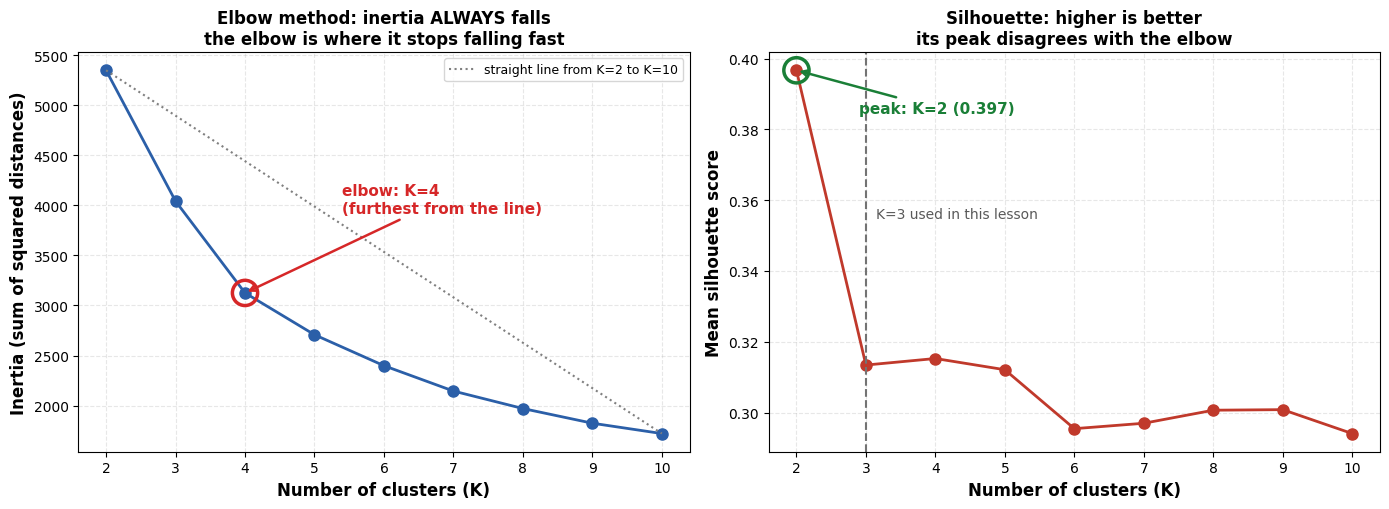


📌 Elbow (furthest point from the chord): K=4
📌 Silhouette peak                      : K=2 (0.3967)
📌 Silhouette at the K we use (K=3)     : 0.3134


In [12]:
# CELL: Plot both K-selection curves and MARK the K each one picks.
# WHY: the lesson's claim is that the two criteria disagree. Draw the
#      disagreement instead of describing it.

# Find the elbow the same way a human eyes it: the K whose point sits furthest
# from the straight line joining the first and last point of the inertia curve.
curve = np.column_stack([k_range, inertias]).astype(float)
start, end = curve[0], curve[-1]
direction = (end - start) / np.linalg.norm(end - start)
projections = start + np.outer((curve - start) @ direction, direction)
elbow_k = k_range[int(np.argmax(np.linalg.norm(curve - projections, axis=1)))]
peak_k = k_range[int(np.argmax(silhouette_scores))]

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))

# ---- left: inertia + the chord used to locate the elbow ----
axes[0].plot(k_range, inertias, 'o-', color='#2b5fa8', linewidth=2, markersize=8)
axes[0].plot([k_range[0], k_range[-1]], [inertias[0], inertias[-1]], ':', color='0.5',
             linewidth=1.5, label='straight line from K=2 to K=10')
axes[0].scatter([elbow_k], [inertias[k_range.index(elbow_k)]], s=330, facecolors='none',
                edgecolors='#d62728', linewidths=2.5, zorder=5)
axes[0].annotate(f'elbow: K={elbow_k}\n(furthest from the line)',
                 xy=(elbow_k, inertias[k_range.index(elbow_k)]),
                 xytext=(elbow_k + 1.4, inertias[k_range.index(elbow_k)] + 800),
                 arrowprops=dict(arrowstyle='->', color='#d62728', linewidth=1.8),
                 color='#d62728', fontweight='bold', fontsize=11)
axes[0].set_xlabel('Number of clusters (K)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Inertia (sum of squared distances)', fontsize=12, fontweight='bold')
axes[0].set_title('Elbow method: inertia ALWAYS falls\nthe elbow is where it stops falling fast',
                  fontsize=12, fontweight='bold')
axes[0].set_xticks(k_range)
axes[0].legend(fontsize=9, loc='upper right')
axes[0].grid(True, alpha=0.3, linestyle='--')

# ---- right: silhouette + its peak ----
axes[1].plot(k_range, silhouette_scores, 'o-', color='#c0392b', linewidth=2, markersize=8)
axes[1].scatter([peak_k], [max(silhouette_scores)], s=330, facecolors='none',
                edgecolors='#1a7f37', linewidths=2.5, zorder=5)
axes[1].annotate(f'peak: K={peak_k} ({max(silhouette_scores):.3f})',
                 xy=(peak_k, max(silhouette_scores)),
                 xytext=(peak_k + 0.9, max(silhouette_scores) - 0.012),
                 arrowprops=dict(arrowstyle='->', color='#1a7f37', linewidth=1.8),
                 color='#1a7f37', fontweight='bold', fontsize=11)
axes[1].axvline(3, linestyle='--', color='0.45', linewidth=1.5)
axes[1].annotate('K=3 used in this lesson', xy=(3, 0.355), xytext=(3.15, 0.355),
                 color='0.35', fontsize=10)
axes[1].set_xlabel('Number of clusters (K)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Mean silhouette score', fontsize=12, fontweight='bold')
axes[1].set_title('Silhouette: higher is better\nits peak disagrees with the elbow',
                  fontsize=12, fontweight='bold')
axes[1].set_xticks(k_range)
axes[1].grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('optimal_k.png', dpi=150, bbox_inches='tight')
print("\n✓ Plot saved as 'optimal_k.png'")
plt.show()

print(f"\n📌 Elbow (furthest point from the chord): K={elbow_k}")
print(f"📌 Silhouette peak                      : K={peak_k} ({max(silhouette_scores):.4f})")
print(f"📌 Silhouette at the K we use (K=3)     : {silhouette_scores[k_range.index(3)]:.4f}")


**Read the figure:** the left curve never rises — inertia is guaranteed to fall as K grows, so its
value alone can never choose K. The red circle marks the point that sits furthest from the dotted chord
joining K=2 to K=10; that is the "elbow", and here it lands on **K=4**. The right curve peaks at
**K=2 (0.397)** and then drops to a flat band around 0.30–0.32 for every larger K. The dashed grey line
marks the K=3 we actually used. **The two criteria point at three different numbers (2, 3, 4) on the same
data — so "optimal K" is a judgement call, not a measurement.**

In [13]:
# Find optimal K using both methods
print("\n" + "=" * 60)
print("💡 Interpreting Optimal K Results")
print("=" * 60)

# Silhouette method: pick the K with the highest silhouette score
best_k_silhouette = k_range[int(np.argmax(silhouette_scores))]
print(f"\n📊 Silhouette Method: Best K = {best_k_silhouette} (score = {max(silhouette_scores):.4f})")

print("\n📊 Elbow Method: Look at the LEFT plot above")
print(" - The inertia drop slows noticeably around K=3-4 (the 'elbow')")
print(" - After the elbow, adding clusters barely improves tightness")

print("\n💡 The two methods can DISAGREE - that's normal!")
print(f" - Silhouette prefers K={best_k_silhouette} (two broad groups: higher-crime vs safer communities)")
print(" - The elbow suggests ~3-4 clusters (adds finer-grained profiles)")
print(" - Use DOMAIN KNOWLEDGE to make the final call")
print(" - For intelligence analysis, K=3 gives more actionable groups than K=2,")
print("   which is why we used K=3 in the demonstration above")


💡 Interpreting Optimal K Results

📊 Silhouette Method: Best K = 2 (score = 0.3967)

📊 Elbow Method: Look at the LEFT plot above
 - The inertia drop slows noticeably around K=3-4 (the 'elbow')
 - After the elbow, adding clusters barely improves tightness

💡 The two methods can DISAGREE - that's normal!
 - Silhouette prefers K=2 (two broad groups: higher-crime vs safer communities)
 - The elbow suggests ~3-4 clusters (adds finer-grained profiles)
 - Use DOMAIN KNOWLEDGE to make the final call
 - For intelligence analysis, K=3 gives more actionable groups than K=2,
   which is why we used K=3 in the demonstration above



5. Compare Different K Values



✓ Plot saved as 'kmeans_comparison.png'


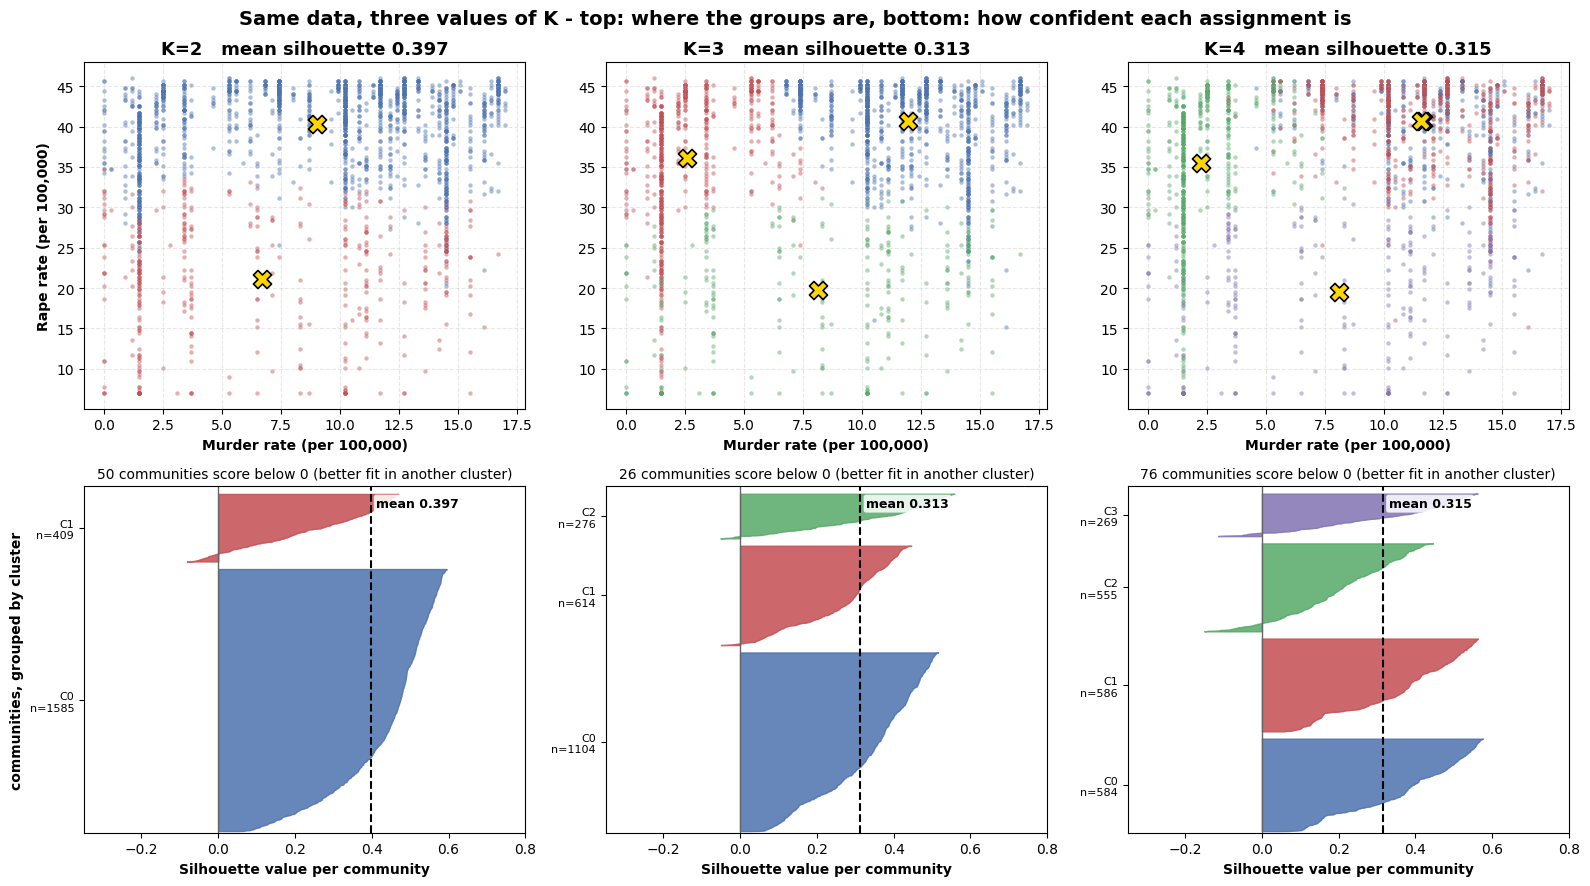


💡 What to notice:
   - Cluster NUMBERS are arbitrary: cluster 0 at K=2 is not cluster 0 at K=3
   - K=2: one huge cluster (~1,585) plus a small one - coarse but confident
   - K=3: the huge cluster splits; mean silhouette drops, yet FEWER
     communities score below zero than at K=2
   - K=4: another split, mean silhouette flat, more negative communities
   - Choosing K is a TRADE-OFF between detail and cluster quality!


In [14]:
# CELL: Compare K=2, 3, 4 twice over - as a map, and as a silhouette diagram.
# WHY: the map shows WHICH communities get split; the silhouette diagram shows
#      how confident the assignment is, community by community. One picture,
#      two independent readings of the same three models.
print("\n" + "=" * 60)
print("5. Compare Different K Values")
print("=" * 60)

from sklearn.metrics import silhouette_samples   # per-community silhouette values

compare_ks = [2, 3, 4]
palette = ['#4C72B0', '#C44E52', '#55A868', '#8172B2']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for col, k in enumerate(compare_ks):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k = km.fit_predict(X_scaled)
    centers_k = scaler.inverse_transform(km.cluster_centers_)
    sil_k = silhouette_score(X_scaled, labels_k)
    sil_each = silhouette_samples(X_scaled, labels_k)   # one value per community

    # ---- top row: the map (Murder vs Rape - the axes that show the groups) ----
    ax = axes[0, col]
    for c in range(k):
        mask = labels_k == c
        ax.scatter(X[mask, i_murder], X[mask, i_rape], c=palette[c], s=10,
                   alpha=0.45, linewidths=0)
    ax.scatter(centers_k[:, i_murder], centers_k[:, i_rape], c='gold', marker='X',
               s=170, edgecolors='black', linewidths=1.2, zorder=5)
    ax.set_title(f'K={k}   mean silhouette {sil_k:.3f}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Murder rate (per 100,000)', fontsize=10, fontweight='bold')
    if col == 0:
        ax.set_ylabel('Rape rate (per 100,000)', fontsize=10, fontweight='bold')
    ax.grid(True, alpha=0.3, linestyle='--')

    # ---- bottom row: the silhouette diagram ----
    # One horizontal bar per community, sorted inside its cluster.
    # Bar length = how much better this community fits its own cluster than the
    # next-best one. Negative = it would fit a different cluster better.
    ax = axes[1, col]
    y = 10
    ticks, tick_labels = [], []
    for c in range(k):
        values = np.sort(sil_each[labels_k == c])
        ax.fill_betweenx(np.arange(y, y + len(values)), 0, values,
                         color=palette[c], alpha=0.85)
        ticks.append(y + len(values) / 2)
        tick_labels.append(f'C{c}\nn={len(values)}')
        y += len(values) + 45
    ax.axvline(sil_k, color='black', linestyle='--', linewidth=1.5)
    ax.text(sil_k + 0.015, y * 0.94, f'mean {sil_k:.3f}', fontsize=9, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='none', alpha=0.85))
    ax.axvline(0, color='0.4', linewidth=1)
    ax.set_yticks(ticks)
    ax.set_yticklabels(tick_labels, fontsize=8)
    ax.set_xlim(-0.35, 0.8)
    ax.set_ylim(0, y)
    ax.set_xlabel('Silhouette value per community', fontsize=10, fontweight='bold')
    if col == 0:
        ax.set_ylabel('communities, grouped by cluster', fontsize=10, fontweight='bold')
    ax.set_title(f'{int((sil_each < 0).sum())} communities score below 0 '
                 f'(better fit in another cluster)', fontsize=10)

fig.suptitle('Same data, three values of K - top: where the groups are, '
             'bottom: how confident each assignment is',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('kmeans_comparison.png', dpi=150, bbox_inches='tight')
print("\n✓ Plot saved as 'kmeans_comparison.png'")
plt.show()

print("\n💡 What to notice:")
print("   - Cluster NUMBERS are arbitrary: cluster 0 at K=2 is not cluster 0 at K=3")
print("   - K=2: one huge cluster (~1,585) plus a small one - coarse but confident")
print("   - K=3: the huge cluster splits; mean silhouette drops, yet FEWER")
print("     communities score below zero than at K=2")
print("   - K=4: another split, mean silhouette flat, more negative communities")
print("   - Choosing K is a TRADE-OFF between detail and cluster quality!")


**Read the figure:** the top row is a map — as K grows, the large group is cut into smaller ones, and
you can see *which* communities get separated (the gold X's are the centroids). The bottom row is the
same three models judged community by community: each thin horizontal bar is one community, and its
length is how much better it fits its own cluster than the next-best one. Bars to the **left of zero**
are communities that would fit a different cluster better.

Two honest readings live in this one picture. K=2 has the highest *mean* silhouette (the dashed line is
furthest right) but it is a blunt split into a 1,585-community block and a 409-community one. K=3 has a
lower mean, yet **fewer** communities fall below zero — the count printed above each silhouette panel gives the exact
numbers (50 at K=2, 26 at K=3, 76 at K=4). **A single average can hide who is being misfiled; always look at the distribution too.**

In [15]:
# Part 1 Summary: Clustering Results Table
print("\n" + "=" * 60)
print("Part 1 Summary: Clustering Results")
print("=" * 60)

print(f"\n📊 Dataset: {len(df)} communities, {len(feature_cols)} features (scaled with StandardScaler)")
print(f"\n📊 Demonstration model (K=3):")
print(f" - Inertia: {inertia:.2f}")
print(f" - Silhouette Score: {sil_score:.4f} (fair separation - normal for real-world data)")
print(f" - Cluster sizes: {df['Cluster'].value_counts().sort_index().tolist()}")
print(f"\n📊 Optimal K search (K=2 to 10):")
print(f" - Best silhouette: K={best_k_silhouette} (score = {max(silhouette_scores):.4f})")
print(f" - Elbow method: inertia drop slows around K=3-4")
print("\n✅ Key takeaways from Part 1:")
print(" - ALWAYS scale features before K-Means (distance-based algorithm)")
print(" - K-Means finds groups WITHOUT labels (unsupervised learning)")
print(" - Elbow + Silhouette help choose K, but they can disagree")
print(" - Domain knowledge makes the final decision on K")


Part 1 Summary: Clustering Results

📊 Dataset: 1994 communities, 4 features (scaled with StandardScaler)

📊 Demonstration model (K=3):
 - Inertia: 4041.38
 - Silhouette Score: 0.3134 (fair separation - normal for real-world data)
 - Cluster sizes: [1104, 614, 276]

📊 Optimal K search (K=2 to 10):
 - Best silhouette: K=2 (score = 0.3967)
 - Elbow method: inertia drop slows around K=3-4

✅ Key takeaways from Part 1:
 - ALWAYS scale features before K-Means (distance-based algorithm)
 - K-Means finds groups WITHOUT labels (unsupervised learning)
 - Elbow + Silhouette help choose K, but they can disagree
 - Domain knowledge makes the final decision on K


## 💬 Discuss

From the printed results: K=3 gives silhouette 0.3134 with cluster sizes **1104 / 614 / 276**;
the best silhouette is **K=2 at 0.3967**; every K from 2 to 10 scores between 0.29 and 0.40.

1. **Who decides K — the metric or the analyst?** Silhouette says 2, the elbow says 3–4, and we used 3
   for operational reasons. Write the single sentence you would put in the report to justify K=3 to a
   reviewer who has read the silhouette scores and disagrees. Then write the sentence that reviewer
   would write back.

2. **One cluster holds 1,104 of 1,994 communities — 55% of everything.** Is that a segment or a
   leftover bin? What could you actually *do* with it? At what size does a cluster stop being a
   finding and start being "the rest"?

3. **Every silhouette score here sits between 0.29 and 0.40 — "fair", never "good".** Two readings:
   (a) this data has no natural clusters and we are imposing them; (b) real social data never
   separates cleanly and 0.40 is as good as it gets. Both are defensible from these numbers alone.
   What evidence — inside or outside this dataset — would decide between them?


## Part 2: Decision Framework - When to Use K-Means Clustering

**BEFORE**: You've learned how to build K-Means models and find optimal K. But when should you use K-Means vs other clustering methods?

**AFTER**: You'll have a clear decision framework to determine if K-Means is the right choice for your clustering problem!

**Why this matters**: Using K-Means when it's not appropriate leads to:
- **Poor clusters** → K-Means assumes spherical clusters, may fail on other shapes
- **Wrong number of clusters** → Need to know K beforehand
- **Wrong method** → Other methods may work better for your data

**Transition**: Now that you understand how K-Means works, let's learn when to use it!

---

### 🎯 Decision Framework: Is K-Means Appropriate?

**Key Question**: Should I use **K-MEANS**, **HIERARCHICAL CLUSTERING**, or other methods?

#### Decision Tree:

```
What type of problem do you have?
├─ SUPERVISED LEARNING (have labels) → Use classification/regression ❌
│   └─ Why? K-Means is for unsupervised learning (no labels)
│
└─ UNSUPERVISED LEARNING (no labels) → Check cluster shape:
    ├─ Spherical clusters (round, ball-shaped)? → Use K-MEANS ✅
    │   └─ Why? K-Means assumes spherical clusters
    │
    ├─ Know number of clusters? → Use K-MEANS ✅
    │   └─ Why? K-Means requires specifying K
    │
    ├─ Don't know number of clusters? → Use HIERARCHICAL CLUSTERING ✅
    │   └─ Why? Hierarchical doesn't require K
    │
    ├─ Non-spherical clusters (elongated, irregular)? → Use OTHER METHODS ⚠️
    │   └─ Use: DBSCAN, Hierarchical, or other methods
    │
    └─ Large dataset (> 10,000)? → Use K-MEANS ✅
        └─ Why? K-Means is fast and scalable
```

#### Detailed Decision Process:

```
Step 1: Problem Type
├─ Supervised (have labels) → ❌ NOT APPROPRIATE
│   └─ Use: Classification or Regression
│
└─ Unsupervised (no labels) → Continue to Step 2

Step 2: Cluster Shape
├─ Spherical/round clusters → ✅ K-MEANS
│   └─ Why? K-Means assumes spherical clusters
│
├─ Elongated/irregular clusters → ⚠️ MAY NOT BE APPROPRIATE
│   └─ Use: DBSCAN, Hierarchical, or other methods
│
└─ Unknown shape → Try K-MEANS first, check results

Step 3: Number of Clusters
├─ Know K (number of clusters) → ✅ K-MEANS
│   └─ Why? K-Means requires specifying K
│
└─ Don't know K → ⚠️ MAY NOT BE APPROPRIATE
    ├─ Can estimate K (Elbow Method) → Use K-MEANS
    └─ Can't estimate K → Use HIERARCHICAL CLUSTERING

Step 4: Dataset Size
├─ Large dataset (> 10,000) → ✅ K-MEANS
│   └─ Why? K-Means is fast and scalable
│
└─ Small dataset (< 100) → ⚠️ MAY USE HIERARCHICAL
    └─ Use: Hierarchical or K-Means (both work)
```

---

### 📊 Comparison Table: K-Means vs Other Clustering Methods

| Method | When to Use | Pros | Cons | Example |
|--------|-------------|------|------|---------|
| **K-Means** | Spherical clusters, known K, large datasets | • Fast<br>• Scalable<br>• Simple<br>• Works well with spherical clusters | • Need to specify K<br>• Assumes spherical clusters<br>• Sensitive to initialization | Customer segmentation, image compression |
| **Hierarchical** | Unknown K, need dendrogram, small-medium data | • No need to specify K<br>• Dendrogram visualization<br>• Flexible | • Slow for large data<br>• More complex<br>• Computationally expensive | Gene clustering, small datasets |
| **DBSCAN** | Irregular shapes, noise present, unknown K | • Handles irregular shapes<br>• Finds noise/outliers<br>• No need to specify K | • Sensitive to parameters<br>• Can fail with varying densities | Anomaly detection, irregular clusters |
| **Gaussian Mixture** | Overlapping clusters, probabilistic | • Handles overlapping clusters<br>• Probabilistic assignment | • More complex<br>• Slower | Overlapping groups, soft clustering |

---

### ✅ When K-Means IS Appropriate

**Use K-Means when:**

1. **Spherical Clusters** ✅
   - Clusters are round, ball-shaped
   - K-Means assumes spherical clusters
   - **Example**: Customer segments (similar customers form round groups)

2. **Know Number of Clusters** ✅
   - Know or can estimate K
   - Can use Elbow Method or domain knowledge
   - **Example**: Know you want 3 customer segments

3. **Large Dataset** ✅
   - More than 10,000 samples
   - K-Means is fast and scalable
   - **Example**: 100,000+ customer records

4. **Fast Clustering Needed** ✅
   - Need quick results
   - K-Means is computationally efficient
   - **Example**: Real-time customer segmentation

5. **Similar Cluster Sizes** ✅
   - Clusters are roughly similar in size
   - K-Means works best with balanced clusters
   - **Example**: Balanced customer groups

---

### ❌ When K-Means IS NOT Appropriate

**Don't use K-Means when:**

1. **Non-Spherical Clusters** ❌
   - Clusters are elongated, irregular, or crescent-shaped
   - K-Means assumes spherical clusters
   - **Use Instead**: DBSCAN, Hierarchical Clustering

2. **Unknown Number of Clusters** ❌
   - Can't estimate K
   - Elbow Method unclear
   - **Use Instead**: Hierarchical Clustering (shows all possible K)

3. **Varying Cluster Sizes** ❌
   - Clusters are very different in size
   - K-Means biased toward larger clusters
   - **Use Instead**: Hierarchical Clustering or DBSCAN

4. **Noise/Outliers Present** ❌
   - Many outliers or noise points
   - K-Means assigns all points to clusters
   - **Use Instead**: DBSCAN (identifies noise)

5. **Overlapping Clusters** ❌
   - Clusters overlap significantly
   - K-Means assigns each point to one cluster
   - **Use Instead**: Gaussian Mixture Models (probabilistic)

---

### 📊 Real-World Examples

#### Example 1: Customer Segmentation ✅ APPROPRIATE
- **Problem**: Segment customers into groups
- **Cluster Shape**: Spherical (similar customers form round groups)
- **Known K**: Yes (want 3-5 segments)
- **Dataset**: Large (50,000 customers)
- **Decision**: ✅ Use K-Means
- **Reasoning**: Spherical clusters, known K, large dataset, fast

#### Example 2: Image Compression ✅ APPROPRIATE
- **Problem**: Compress images by reducing colors
- **Cluster Shape**: Spherical (color clusters)
- **Known K**: Yes (want 16 or 256 colors)
- **Dataset**: Large (many pixels)
- **Decision**: ✅ Use K-Means
- **Reasoning**: Spherical clusters, known K, large dataset

#### Example 3: Gene Clustering ❌ NOT APPROPRIATE
- **Problem**: Cluster genes by expression
- **Cluster Shape**: Irregular, elongated
- **Known K**: No (don't know how many gene groups)
- **Dataset**: Small-medium (1,000 genes)
- **Decision**: ❌ Use Hierarchical Clustering
- **Reasoning**: Irregular shapes, unknown K, need dendrogram

#### Example 4: Anomaly Detection ❌ NOT APPROPRIATE
- **Problem**: Find outliers in network traffic
- **Cluster Shape**: Irregular, noise present
- **Known K**: No
- **Noise**: Many outliers
- **Decision**: ❌ Use DBSCAN
- **Reasoning**: Irregular shapes, noise present, need to identify outliers

---

### ✅ Key Takeaways

1. **Spherical clusters → K-Means** - Use when clusters are round
2. **Known K → K-Means** - Need to specify number of clusters
3. **Large data → K-Means** - Fast and scalable
4. **Unknown K → Hierarchical** - Use when you don't know K
5. **Irregular shapes → DBSCAN** - Use for non-spherical clusters
6. **Use Elbow Method** - To find optimal K for K-Means
7. **Visualize clusters** - Plot to check if they're spherical

---

### 🎓 Practice Decision-Making

**Scenario 1**: Segmenting 20,000 customers into 5 groups
- **Cluster Shape**: Spherical (similar customers)
- **Known K**: Yes (5 segments)
- **Dataset**: Large (20,000)
- **Decision**: ✅ K-Means (spherical, known K, large dataset)

**Scenario 2**: Clustering genes by expression (unknown number of groups)
- **Cluster Shape**: Irregular, elongated
- **Known K**: No
- **Dataset**: Medium (2,000 genes)
- **Decision**: ❌ Hierarchical Clustering (irregular shapes, unknown K)

**Scenario 3**: Compressing images to 16 colors
- **Cluster Shape**: Spherical (color clusters)
- **Known K**: Yes (16 colors)
- **Dataset**: Large (millions of pixels)
- **Decision**: ✅ K-Means (spherical, known K, large dataset, fast)

---

**Connection to Next Steps**: 
- 📓 **Example 2: Hierarchical Clustering** - For unknown K and dendrograms
- 📓 **Example 3: PCA** - For dimensionality reduction before clustering
- 📓 **All Clustering Projects** - K-Means is the foundation of clustering

In [16]:
# 5. Summary Table
print("\n" + "=" * 60)
print("5. Clustering Summary")
print("=" * 60)
summary_data = {
 'K': k_range, 'Inertia': [f"{x:.2f}" for x in inertias],
 'Silhouette Score': [f"{x:.4f}" for x in silhouette_scores]
}
# pd.DataFrame(data)
# - pd.DataFrame(): Creates pandas DataFrame (2D table-like structure)
# - data: Dictionary where keys become column names, values become column data
# - Each key-value pair: key = column name, value = list of values for that column
# - Returns DataFrame with rows and columns
# - DataFrame is the main pandas data structure (like Excel spreadsheet in Python)
summary_df = pd.DataFrame(summary_data)
print("\nClustering Metrics for Different K:")
print(summary_df.to_string(index=False))
print("\n" + "=" * 60)
# Keep summary but we'll add limitations section after this


5. Clustering Summary

Clustering Metrics for Different K:
 K Inertia Silhouette Score
 2 5347.86           0.3967
 3 4041.38           0.3134
 4 3124.93           0.3153
 5 2707.60           0.3121
 6 2398.46           0.2954
 7 2145.23           0.2970
 8 1970.75           0.3007
 9 1824.09           0.3008
10 1720.82           0.2941



## Part 3: Limitations of K-Means

**BEFORE**: We've learned when K-Means works well. But what are its limitations?

**AFTER**: We'll see K-Means' **main limitation** - you need to specify K before running the algorithm!

**Why this matters**: 
- In real-world problems, you often **don't know** how many clusters exist
- K-Means requires you to **choose K first** (trial and error with elbow method)
- If you choose wrong K, you get poor clustering results
- This limitation leads us to **Hierarchical Clustering** (next notebook) - it doesn't require pre-specifying K!

**Transition**: Now that you know when to use K-Means, let's understand its limitations!

---

## The Problem: Need to Know K Beforehand

---

### 🔍 Real-World Scenario

**Example**: Customer segmentation where you don't know how many customer segments exist. You have to try different K values and hope you pick the right one.

**The Limitation**: 
- K-Means requires you to **specify K** (number of clusters) before running
- You might try K=3, K=4, K=5... but which is correct?
- Elbow method helps, but it's not always clear
- What if the optimal K is unclear?

**Solution**: Use **Hierarchical Clustering** (next notebook) - it shows ALL possible clusterings and you can choose K after seeing the results!

In [17]:
# CELL: Honest wrap-up of K-Means' biggest practical limitation.
# WHY: K must be chosen BEFORE running - real projects rarely know it.
print("\n" + "=" * 60)
print("🚫 Limitations of K-Means")
print("=" * 60)
print("\n📊 K-Means Limitation: Need to Know K Beforehand")
print("\n🔍 What We Observed:")
print(" - We used K=3 as an example (to demonstrate clustering)")
print(" - But in real-world problems, you often DON'T know the true number of clusters")
print(" - K-Means REQUIRES you to specify K before running the algorithm")
print("\n❌ The Problem:")
print(" - You have to guess or try different K values")
print(" - Elbow method helps, but sometimes the 'elbow' is unclear")
print(" - Wrong K → Poor clustering results")
print(" - Example: If true clusters is 4, but you use K=3, you'll get bad clusters")
print("\n💡 Key Limitation:")
print(" - K-Means assumes you know K beforehand")
print(" - This is a major limitation for exploratory data analysis")
print(" - When you don't know K, you have to try multiple values")
print("\n✅ Solution: Hierarchical Clustering")
print(" - Hierarchical Clustering doesn't require pre-specifying K")
print(" - It creates a dendrogram showing ALL possible clusterings")
print(" - You can choose K after seeing the results")
print(" - Next notebook will show this solution!")
print("\n🔗 Next Notebook:")
print(" - Example 2: Hierarchical Clustering solves this limitation")
print(" - Shows dendrogram with all possible clusterings")
print(" - You choose K after seeing the hierarchical structure!")


🚫 Limitations of K-Means

📊 K-Means Limitation: Need to Know K Beforehand

🔍 What We Observed:
 - We used K=3 as an example (to demonstrate clustering)
 - But in real-world problems, you often DON'T know the true number of clusters
 - K-Means REQUIRES you to specify K before running the algorithm

❌ The Problem:
 - You have to guess or try different K values
 - Elbow method helps, but sometimes the 'elbow' is unclear
 - Wrong K → Poor clustering results
 - Example: If true clusters is 4, but you use K=3, you'll get bad clusters

💡 Key Limitation:
 - K-Means assumes you know K beforehand
 - This is a major limitation for exploratory data analysis
 - When you don't know K, you have to try multiple values

✅ Solution: Hierarchical Clustering
 - Hierarchical Clustering doesn't require pre-specifying K
 - It creates a dendrogram showing ALL possible clusterings
 - You can choose K after seeing the results
 - Next notebook will show this solution!

🔗 Next Notebook:
 - Example 2: Hierarchica

## ⚠️ Where this breaks

- **k-means minimises distance to a centroid, so it finds round, similarly sized, similarly dense
  blobs.** It will cut one long thin group in half and merge two touching ones, and the silhouette
  score will not object, because silhouette is built on the same distance assumption. Grading a
  distance-based method with a distance-based ruler is not an independent check.
- **It has no "none of the above".** Every point is assigned. One extreme community drags its centroid
  toward it and distorts the cluster around it — there is no outlier category.
- **It needs scaling and it needs restarts.** Pure Euclidean distance means an unscaled feature
  dominates; and the result depends on where the centroids started, which is why `n_init` exists.
- **The assumption that must hold:** "similar" really does mean "close in scaled Euclidean space", and
  you already know how many groups there should be.
- **Cheaper and better alternatives:** DBSCAN or HDBSCAN when clusters are irregular or when some
  points should belong to nothing; hierarchical clustering (the next lesson) when you do not want to
  fix k in advance; and — if what you actually need is "high / medium / low crime" — a quantile split
  on a single column, which is reproducible, explainable, and requires no silhouette score to defend.


---

## ❓ Common Student Questions

**Q: How do I choose the right K value?**
- **Answer**: Use Elbow Method or Silhouette Score:
  - **Elbow Method**: Plot inertia vs K, look for "elbow" (where decrease slows)
  - **Silhouette Score**: Pick K with highest silhouette score (more objective)
  - **Try both**: Methods may disagree - use domain knowledge to decide
  - **Rule of thumb**: Start with K=2, try 3, 4, 5, pick the one with best silhouette score

**Q: Why does K-Means need feature scaling?**
- **Answer**: K-Means is distance-based (finds nearest centroid):
  - **Problem**: Features on different scales (age: 0-100, income: 0-100000) → distance dominated by larger scale
  - **Issue**: Income feature will dominate distance calculations, age will be ignored
  - **Solution**: Scale all features to same range (StandardScaler) → fair distance calculations
  - **Rule**: ALWAYS scale features before K-Means (critical!)

**Q: What's the difference between supervised and unsupervised learning?**
- **Answer**: 
  - **Supervised**: Has labels (target variable) - learn from labeled examples
    - Example: Classification (predict tumor type from measurements)
  - **Unsupervised**: No labels - find patterns in data automatically
    - Example: Clustering (find groups of similar customers without labels)
  - **K-Means**: Unsupervised (no labels needed, finds groups automatically)

**Q: What is inertia and what does it mean?**
- **Answer**: Inertia = sum of squared distances from points to their centroids:
  - **Lower inertia**: Points are closer to centroids (tighter clusters) - better!
  - **Higher inertia**: Points are far from centroids (loose clusters) - worse!
  - **Use**: Compare different K values (lower is better, but watch for overfitting)
  - **Note**: Inertia always decreases as K increases (more clusters = smaller distances)

**Q: What is silhouette score and how do I interpret it?**
- **Answer**: Silhouette score measures how well-separated clusters are:
  - **Range**: -1 to 1 (higher is better)
  - **> 0.7**: Excellent separation ✅
  - **0.5-0.7**: Good separation ✅
  - **0.3-0.5**: Fair separation ⚠️
  - **< 0.3**: Poor separation ⚠️
  - **Use**: Pick K with highest silhouette score (more reliable than elbow method)

**Q: Why is my silhouette score 'fair' (0.3-0.5) and not 'good' (0.5+) or 'excellent' (0.7+)?**
- **Answer**: **'Fair' is actually NORMAL for real-world data!** Here's why:
  - **Real-world data is messy**: Natural data doesn't form perfectly separated clusters
  - **Gradual transitions**: Data exists on a spectrum (not sharp boundaries)
  - **Multiple features**: Clusters overlap in some dimensions (complex patterns)
  - **Comparison**:
    - Synthetic data (perfect clusters): 0.7-0.9 (EXCELLENT) ✅
    - Real-world data (natural patterns): 0.3-0.5 (FAIR-GOOD) ✅ ← **This is normal!**
  - **What 'fair' means**:
    - ✅ Clusters ARE meaningful and useful
    - ✅ Patterns ARE discovered
    - ⚠️ BUT clusters have SOME overlap (not perfectly separated)
  - **Is 'fair' good enough?**: **YES!** Focus on whether clusters give insights, not just the score
  - **How to improve** (if needed):
    - Try different K values (use optimal K from Elbow/Silhouette)
    - Try different features (remove features that don't help separation)
    - Try different algorithms (DBSCAN, Hierarchical)
    - **BUT**: Don't obsess - 'fair' is often good enough for real-world data!

**Q: Can K-Means handle non-spherical clusters?**
- **Answer**: **NO!** K-Means assumes spherical (circular) clusters:
  - **Problem**: K-Means works best when clusters are round/spherical
  - **Issue**: Fails on elongated, irregular, or non-spherical clusters
  - **Solution**: Use other clustering methods (DBSCAN, Hierarchical Clustering)
  - **Check**: Visualize clusters - if they look non-spherical, K-Means may not work well

**Q: What happens if I choose the wrong K?**
- **Answer**: You get poor clustering results:
  - **K too small**: Clusters are too large (underfitting - groups that should be separate are merged)
  - **K too large**: Clusters are too small (overfitting - groups that should be together are split)
  - **Solution**: Use Elbow Method or Silhouette Score to find optimal K
  - **Visualize**: Always plot clusters to verify K makes sense

**Q: How is K-Means different from classification?**
- **Answer**: 
  - **Classification (supervised)**: Predict labels for new data (has training labels)
  - **Clustering (unsupervised)**: Find groups in data (no labels, discovers patterns)
  - **K-Means**: Finds groups automatically, doesn't predict labels for new data
  - **Use classification**: When you have labels and want to predict
  - **Use clustering**: When you have no labels and want to discover groups

**Q: The dataset has a 'State' column - isn't that a label? How is this unsupervised?**
- **Answer**: **NO! The 'State' column is NOT a label** - here's why:
  - **Label/Target**: What you want to predict (e.g., "High Crime" vs "Low Crime")
  - **Identifier**: Just a name/ID for each row (like row numbers)
  - **State column**: It's just an identifier (Community_1, Community_2, etc.) - NOT a label!
  - **What we use**: ONLY the 4 features (Murder, Assault, UrbanPop, Rape) for clustering
  - **What we exclude**: State column is excluded from clustering (just for reference)
  - **Why unsupervised**: There is NO target variable telling us which communities belong together
  - **Example**: 
    - ❌ Supervised would have: "High Crime" or "Low Crime" labels
    - ✅ Unsupervised: NO labels - algorithm discovers groups automatically
    - ✅ Our dataset: NO target variable → Unsupervised learning!

**Q: When we cluster without labels, what do we see/learn? What's the output?**
- **Answer**: **Clustering gives us cluster assignments and patterns** - here's what we get:
  - **Cluster Assignments**: Each community gets assigned to a cluster (0, 1, 2, etc.)
  - **Cluster Centroids**: Average crime pattern for each cluster (what makes each group unique)
  - **Group Similarity**: Communities in same cluster have similar crime profiles
  - **Group Differences**: Different clusters represent different crime patterns
  - **What we learn**:
    - Which communities have similar patterns (same cluster)
    - What makes clusters different (compare centroids)
    - How many distinct groups exist (K clusters)
    - Which communities need similar strategies (same cluster)
  - **Example Output**:
    - Cluster 0: 1104 communities with high murder + high rape rates (higher-crime communities)
    - Cluster 1: 614 communities with low murder rates (safer communities)
    - Cluster 2: 276 mostly urban communities with moderate crime (urban pattern)
  - **Real-World Value**: 
    - No labels needed → discover patterns automatically
    - Actionable insights → target interventions by cluster
    - Pattern discovery → find hidden groups we didn't know existed
    - Strategic planning → allocate resources based on cluster characteristics
  - **The Power**: We didn't need to label communities - clustering DISCOVERED the groups!

---

## 🎯 Summary: When K-Means Works vs. Limitations

### ✅ K-Means Works Well When:
1. **You Know K**: Number of clusters is known or can be determined clearly
2. **Spherical Clusters**: Clusters are roughly circular/spherical
3. **Similar Cluster Sizes**: Clusters have similar numbers of points
4. **Good Example**: Crime statistics dataset with K=2-3 (crime pattern groups) ✅

### ❌ K-Means Limitations:
1. **Need to Know K**: Must specify number of clusters beforehand ❌
2. **Assumes Spherical Clusters**: Struggles with non-spherical clusters
3. **Sensitive to Initialization**: Different random starts can give different results
4. **Poor with Outliers**: Outliers can heavily influence cluster centers

### 🔍 How to Recognize This Problem in Real Life

**Symptoms You'll See:**
- You don't know how many clusters exist in your data
- Elbow method gives unclear results (no clear "elbow")
- Trying different K values gives very different clustering results
- You need to see all possible clusterings before choosing K

**Diagnosis - Check These Indicators:**
1. Do you know the true number of clusters?
2. Is the elbow in the elbow method clear?
3. Do different K values give very different results?
4. Do you need to explore clustering structure before choosing K?

**Solution:**
- Use **Hierarchical Clustering** (next notebook) - shows all possible clusterings
- Use **Density-Based Clustering** (DBSCAN) - finds clusters of any shape
- Use **Multiple K Values** - try different K and compare results

---

## 🔗 Transition to Next Notebook

**What We Learned:**
- ✅ K-Means works well when you know K
- ✅ K-Means is simple and fast
- ❌ K-Means requires you to specify K beforehand
- ❌ This is a limitation for exploratory data analysis

**The Problem:**
- We need to find clusters without knowing K beforehand
- K-Means requires pre-specifying K
- We need a method that shows all possible clusterings

**Next Notebook: Hierarchical Clustering**
- 📓 **Example 2: Hierarchical Clustering** solves this limitation!
- Creates dendrogram showing ALL possible clusterings
- You can choose K after seeing the hierarchical structure
- No need to pre-specify K! ✅

**This limitation leads us to Hierarchical Clustering - it doesn't require pre-specifying K!**

In [18]:
# Closing banner: hierarchical clustering (next) removes the need to pre-pick K.
print("\n" + "=" * 60)
print("Example 1 Complete! ✓")
print("=" * 60)
print("\n🎯 Next Step: Open Example 2 (Hierarchical Clustering)\nto see how it solves the 'unknown K' problem!")


Example 1 Complete! ✓

🎯 Next Step: Open Example 2 (Hierarchical Clustering)
to see how it solves the 'unknown K' problem!


## 📚 References

1. MacQueen, J. (1967). *Some Methods for Classification and Analysis of Multivariate Observations*. Proceedings of the 5th Berkeley Symposium on Mathematical Statistics and Probability.
2. Lloyd, S. P. (1982). *Least Squares Quantization in PCM*. IEEE Transactions on Information Theory, 28(2), 129–137 (originally circulated 1957).
3. Arthur, D., & Vassilvitskii, S. (2007). *k-means++: The Advantages of Careful Seeding*. SODA 2007.
4. James, G., Witten, D., Hastie, T., & Tibshirani, R. (2021). *An Introduction to Statistical Learning* (2nd ed.), Chapter 12. Springer.
5. Xiao, F., Fu, D., Ding, C., & Fan, J. (2026). *CLUBench: A Clustering Benchmark*. <https://arxiv.org/abs/2605.29933>
6. Wang, Z., & Ye, C. (2024). *Deep Clustering Evaluation: How to Validate Internal Clustering Validation Measures*. <https://arxiv.org/abs/2403.14830>
